In [36]:
import numpy as np
import math
import matplotlib.pyplot as plt
from IPython.display import display, Math

equation1 = lambda x: x[0] * x[0] + x[1] * x[1] - 4
equation2 = lambda x: x[0] - math.exp(x[1]) + 2
eps = 1e-3

# Анализ системы

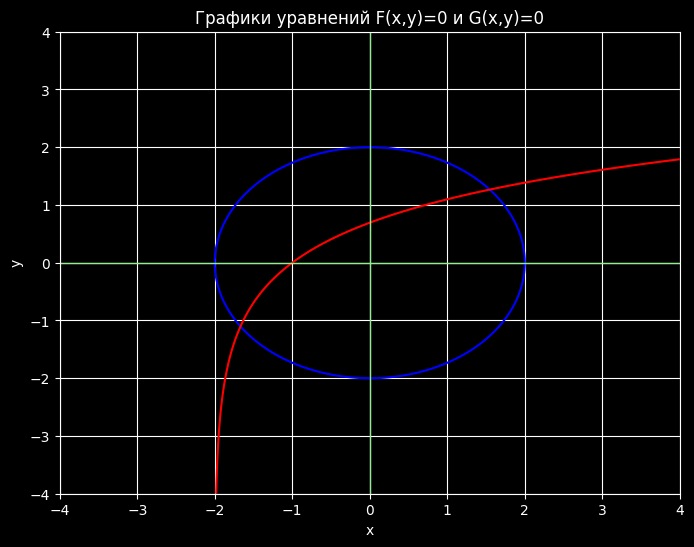

In [37]:
x = y = np.linspace(-4, 4, 400)

equation_xy_1 = lambda X, Y: X**2 + Y**2 - 4
equation_xy_2 = lambda X, Y: X - np.exp(Y) + 2

X, Y = np.meshgrid(x, y)

Z1 = equation_xy_1(X, Y)
Z2 = equation_xy_2(X, Y)

plt.figure(figsize=(8, 6))

plt.contour(X, Y, Z1, levels=[0], colors='blue')
plt.contour(X, Y, Z2, levels=[0], colors='red')

plt.axhline(0, color='lightgreen', linewidth=1)
plt.axvline(0, color='lightgreen', linewidth=1)
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Графики уравнений F(x,y)=0 и G(x,y)=0')
plt.show()

Введём функции норм

In [38]:
def vector_norm(vector):
    vector = np.asarray(vector)
    return np.abs(vector).max()

def matrix_norm(matrix):
    matrix = np.asarray(matrix)
    return np.abs(matrix).sum(axis=1).max()

Зададим функции $\phi$
\begin{align*}
    \phi_1(X) &= \sqrt{4 - x_2^2} \\
    \phi_2(X) &= \ln(x_1 + 2)
\end{align*}

Определим, при каких значениях вектора $X$ норма матрицы Якоби для системы функций $\phi$ будет меньше $1$.

1. Составление матрицы Якоби</br>
- Матрица Якоби $J(X)$ составляется из частных производных заданных функций по каждой из переменных $x_1$ и $x_2$:
$
J(X) = \begin{pmatrix}
\frac{\partial \phi_1}{\partial x_1} & \frac{\partial \phi_1}{\partial x_2} \\[10pt]
\frac{\partial \phi_2}{\partial x_1} & \frac{\partial \phi_2}{\partial x_2}
\end{pmatrix}
$

- Найдем соответствующие частные производные:
\begin{align*}
    \frac{\partial \phi_1}{\partial x_1} &= 0 \\
    \frac{\partial \phi_1}{\partial x_2} &= \frac{-2x_2}{2\sqrt{4 - x_2^2}} = \frac{-x_2}{\sqrt{4 - x_2^2}} \\
    \frac{\partial \phi_2}{\partial x_1} &= \frac{1}{x_1 + 2} \\
    \frac{\partial \phi_2}{\partial x_2} &= 0
\end{align*}

- Подставим найденные производные в матрицу:
$
J(X) = \begin{pmatrix}
0 & \frac{-x_2}{\sqrt{4 - x_2^2}} \\[10pt]
\frac{1}{x_1 + 2} & 0
\end{pmatrix}
$

2. Вычисление нормы
- Норма:
$
\|J\| = \max \left( \left| \frac{-x_2}{\sqrt{4 - x_2^2}} \right|, \left| \frac{1}{x_1 + 2} \right| \right)
$

Подготовка производных и функций $\phi(x)$ для метода простых итераций в матричной форме

3. Решение неравенств
- По условию задачи норма матрицы должна быть строго меньше единицы ($\|J\| < 1$). Это означает, что каждый из ненулевых элементов по модулю должен быть меньше единицы.</br>Получаем систему неравенств:
$
\begin{cases}
\left| \frac{1}{x_1 + 2} \right| < 1 \\[10pt]
\left| \frac{-x_2}{\sqrt{4 - x_2^2}} \right| < 1
\end{cases}
$

- Решим первое неравенство:</br>
С учетом области определения логарифма ($x_1 + 2 > 0 \Rightarrow x_1 > -2$), выражение под модулем положительно. Неравенство примет вид:
\begin{align*}
    \frac{1}{x_1 + 2} &< 1 \\
    1 &< x_1 + 2 \\
    x_1 &> -1
\end{align*}

- Решим второе неравенство:</br>
Учитывая ОДЗ для корня ($4 - x_2^2 > 0 \Rightarrow -2 < x_2 < 2$), возведем обе части неравенства в квадрат, так как обе части неотрицательны:
\begin{align*}
    \frac{x_2^2}{4 - x_2^2} &< 1 \\
    x_2^2 &< 4 - x_2^2 \\
    2x_2^2 &< 4 \\
    x_2^2 &< 2 \\
    -\sqrt{2} &< x_2 < \sqrt{2}
\end{align*}
Полученный интервал $(-\sqrt{2}, \sqrt{2})$ полностью входит в ОДЗ корня $(-2, 2)$.

4. Норма матрицы Якоби меньше $1$ при значениях вектора $X = (x_1, x_2)$, удовлетворяющих условиям:
$ x_1 \in (-1, +\infty), \quad x_2 \in (-\sqrt{2}, \sqrt{2}) $

Возьмём интервал $ x_1 \in [1, 1.75], x_2 \in [1, 1.38] $, так как на графике видно, что искомые корни где-то в области квадрата от 1 до 2

In [39]:
x_range = np.array([[1, 1.75], [1, 1.38]])

Определим функции $\phi$ + их производные.</br>Введём матричные представления системы и функций.

In [40]:
phi1 = lambda x: math.sqrt(4 - x[1] * x[1])
phi2 = lambda x: math.log(x[0] + 2)

def combine_funcs(*funcs):
    return lambda x: np.array([f(x) for f in funcs])

equation = combine_funcs(equation1, equation2)
phi = combine_funcs(phi1, phi2)

In [41]:
equation_derivative = lambda x: np.array(
    [
        [2 * x[0], 2 * x[1]],
        [1, -math.exp(x[1])]
    ]
)

phi_derivative = lambda x: np.array(
    [
        [0, -x[1] / math.sqrt(4 - x[1] * x[1])],
        [1 / (x[0] + 2), 0],
    ]
)

Проверим, что $\phi$ отображается в свою же область определения

In [42]:
def phi_image_range_exact(x_range):
    x0_min, x0_max = x_range[0]
    x1_min, x1_max = x_range[1]

    phi1_min = phi1([0, x1_max])
    phi1_max = phi1([0, x1_min])

    phi2_min = phi2([x0_min, 0])
    phi2_max = phi2([x0_max, 0])

    return np.array([
        [phi1_min, phi1_max],
        [phi2_min, phi2_max],
    ])

def is_invariant_exact(x_range, eps=1e-12):
    image = phi_image_range_exact(x_range)

    ok0 = image[0, 0] >= x_range[0, 0] - eps and image[0, 1] <= x_range[0, 1] + eps
    ok1 = image[1, 0] >= x_range[1, 0] - eps and image[1, 1] <= x_range[1, 1] + eps

    return ok0 and ok1

is_invariant_exact(x_range)

np.True_

Найдём q.</br>
Так как функции монотонны, максимум точно достигается на одной из границ.

In [43]:
max(
    abs(
        matrix_norm(phi_derivative([x_range[0, 0], x_range[1, 0]])),
    ),
    abs(
        matrix_norm(phi_derivative([x_range[0, 0], x_range[1, 1]])),
    ),
    abs(
        matrix_norm(phi_derivative([x_range[0, 1], x_range[1, 0]])),
    ),
    abs(
        matrix_norm(phi_derivative([x_range[0, 1], x_range[1, 1]])),
    ),
)

np.float64(0.9532896799882666)

In [44]:
q = 0.955

Вспомогательные функции для решения через метода крамера и вычисления определителя

In [45]:
def get_det(matrix: np.ndarray, eps=1e-3):
    n, m = matrix.shape

    sign = 1.0

    for col in range(n):
        pivot_row = col
        while pivot_row < n and abs(matrix[pivot_row, col]) < eps:
            pivot_row += 1

        if pivot_row == n:
            return 0.0

        if pivot_row != col:
            matrix[[col, pivot_row]] = matrix[[pivot_row, col]]
            sign *= -1

        pivot = matrix[col, col]

        for row in range(col + 1, n):
            factor = matrix[row, col] / pivot
            matrix[row, col:] -= factor * matrix[col, col:]

    det = sign
    for i in range(n):
        det *= matrix[i, i]

    return det

In [46]:
def cramer(A: np.ndarray, b: np.ndarray, eps=1e-3):
    n, m = A.shape
    det_A = get_det(A)
    if abs(det_A) < eps:
        raise ValueError("Определитель равен 0, система не имеет единственного решения")

    x = np.zeros(n)

    for i in range(n):
        Ai = A.copy()
        Ai[:, i] = b
        x[i] = get_det(Ai, eps) / det_A

    return x

# Метод Ньютона

In [47]:
x_i = np.sum(x_range / 2, axis=1)
iterations = 0
condition = True

while condition:
    delta_x = cramer(equation_derivative(x_i), -equation(x_i))
    x_i += delta_x
    condition = vector_norm(delta_x) > eps
    iterations += 1

x_newton = x_i
for i in range(len(x_newton)):
    display(Math(fr"x_{{{i}}} = {x_newton[i]:.3f}"))
print(f"Итераций: {iterations}")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Итераций: 4


# Метод простых итераций

In [48]:
x_i = x_prev = np.sum(x_range / 2, axis=1)
iterations = 0
condition = True

while condition:
    x_i = phi(x_i)
    condition = q * vector_norm(x_i - x_prev) / (1 - q) > eps
    x_prev = x_i
    iterations += 1

x_iter = x_i
for i in range(len(x_iter)):
    display(Math(fr"x_{{{i}}} = {x_iter[i]:.3f}"))
print(f"Итераций: {iterations}")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Итераций: 12


# Валидация

In [49]:
from scipy.optimize import fsolve

x_0 = np.sum(x_range / 2, axis=1)
solution = fsolve(equation, x_0)
solution

array([1.54799144, 1.26638165])

In [50]:
np.allclose(x_newton, solution, eps)

True

In [51]:
np.allclose(x_iter, solution, eps)

True